# ETF Arbitrage Demo (Standalone Engine + yfinance)

This notebook is an **interview-ready**, fully runnable demo:
- Downloads price data with **yfinance** (and caches locally).
- Implements a small but complete **backtest engine** (positions, cash, PnL, trade log, costs).
- Runs **two versions** of the ETF arbitrage idea:
  1) **Baseline (Capula assignment style)**: synthetic ETF from *rebased components* and trade on divergence.
  2) **Improved**: z-score entry/exit, dollar-neutral sizing, risk controls.

> Tip: Run cells top-to-bottom. If yfinance rate-limits or errors, rerun the download cell or extend the date range.


In [1]:
# If running on a fresh environment (e.g., Colab), uncomment:
# !pip -q install yfinance

import math
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import os


## 1) Download & cache data (yfinance)

In [2]:
# Configuration
ETF_TICKER = "QQQ"  # FANG+ (proxy for 'FAANG' in the assignment)
COMPONENTS = ["NVDA","AAPL","MSFT","AMZN","TSLA","GOOGL","META","GOOG","AVGO","COST"] # FAANG constituents (Google as GOOGL, Facebook as META)
ALL_TICKERS = [ETF_TICKER] + COMPONENTS

START = "2020-01-01"
END = None  # None => today
INTERVAL = "1d"  # "1d" is most reliable

CACHE_PATH = f"prices_{ETF_TICKER}_{START}_{INTERVAL}.csv"

def load_prices_yfinance(tickers: List[str], start: str, end: Optional[str], interval: str, cache_path: str) -> pd.DataFrame:
    """Download adjusted close prices from yfinance; cache to CSV for repeatability."""
    if os.path.exists(cache_path):
        df = pd.read_csv(cache_path, index_col=0, parse_dates=True)
        # ensure all tickers exist; if not, redownload
        if all(t in df.columns for t in tickers):
            return df[tickers].dropna(how="any")

    data = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        interval=interval,
        auto_adjust=True,
        group_by="ticker",
        progress=False,
        threads=True,
    )

    # yfinance returns either:
    # - MultiIndex columns when multiple tickers, or
    # - single-level columns when one ticker
    if isinstance(data.columns, pd.MultiIndex):
        # pick "Close" (already auto-adjusted)
        closes = {}
        for t in tickers:
            if (t, "Close") in data.columns:
                closes[t] = data[(t, "Close")]
            elif (t, "Adj Close") in data.columns:
                closes[t] = data[(t, "Adj Close")]
            else:
                raise ValueError(f"Ticker {t} missing Close/Adj Close in download result.")
        df = pd.DataFrame(closes)
    else:
        # single ticker case
        if "Close" in data.columns:
            df = data[["Close"]].rename(columns={"Close": tickers[0]})
        else:
            raise ValueError("Unexpected yfinance format.")

    df = df.dropna(how="any")
    df.to_csv(cache_path)
    return df

prices = load_prices_yfinance(ALL_TICKERS, START, END, INTERVAL, CACHE_PATH)
display(prices.head())
print("Rows:", len(prices), "| From:", prices.index.min().date(), "To:", prices.index.max().date())


,QQQ,NVDA,AAPL,MSFT,AMZN,TSLA,GOOGL,META,GOOG,AVGO,COST
Date,,,,,,,,,,,
2020-01-02,208.580231,5.971077,72.468254,152.505692,94.900497,28.684000,67.920807,208.324783,67.859543,27.735552,266.497498
2020-01-03,206.669617,5.875504,71.763725,150.606766,93.748497,29.534000,67.565498,207.222473,67.526535,27.030098,266.716919
2020-01-06,208.001282,5.900144,72.335564,150.996002,95.143997,30.102667,69.366394,211.125214,69.191551,26.989666,266.790192
2020-01-07,207.972321,5.971576,71.995338,149.619278,95.343002,31.270666,69.232399,211.582047,69.148376,26.896753,266.369476
2020-01-08,209.535492,5.982776,73.153481,152.002487,94.598503,32.809334,69.725182,213.727051,69.693298,26.561228,269.423096


Rows: 1519 | From: 2020-01-02 To: 2026-01-16


## 2) Minimal trading engine (market orders + costs)

In [3]:
@dataclass
class Position:
    ticker: str
    qty: float  # + long, - short
    avg_price: float  # average entry price
    realized_pnl: float = 0.0

class BacktestEngine:
    def __init__(self, prices: pd.DataFrame, initial_cash: float = 1_000_000.0, commission_bps: float = 1.0, slippage_bps: float = 0.0):
        """commission_bps/slippage_bps are applied per trade notional."""
        self.prices = prices
        self.initial_cash = float(initial_cash)
        self.cash = float(initial_cash)
        self.commission_bps = float(commission_bps)
        self.slippage_bps = float(slippage_bps)
        self.positions: Dict[str, Position] = {}
        self.trades: List[dict] = []
        self.equity_curve: List[dict] = []

    def get_price(self, date, ticker: str) -> float:
        return float(self.prices.loc[date, ticker])

    def _trade_cost(self, notional: float) -> float:
        return abs(notional) * (self.commission_bps + self.slippage_bps) / 10_000.0

    def execute_order(self, date, ticker: str, qty: float):
        """Market order filled at current bar price with optional slippage/costs."""
        if qty == 0:
            return
        px = self.get_price(date, ticker)
        notional = qty * px
        cost = self._trade_cost(notional)
        self.cash -= notional
        self.cash -= cost

        # Update position + realized PnL using average cost method
        if ticker not in self.positions:
            self.positions[ticker] = Position(ticker=ticker, qty=0.0, avg_price=0.0, realized_pnl=0.0)

        pos = self.positions[ticker]
        old_qty = pos.qty
        new_qty = old_qty + qty

        # If same direction or increasing exposure: update avg_price
        if old_qty == 0 or (old_qty > 0 and qty > 0) or (old_qty < 0 and qty < 0):
            # new average price weighted by absolute quantities
            total_qty = abs(old_qty) + abs(qty)
            pos.avg_price = (abs(old_qty) * pos.avg_price + abs(qty) * px) / total_qty
            pos.qty = new_qty
        else:
            # reducing or flipping: realize PnL on the closed portion
            close_qty = min(abs(qty), abs(old_qty)) * (-1 if old_qty > 0 else 1)  # qty that closes old
            # For long old_qty>0, selling qty<0 closes negative close_qty
            # realized = (sell - avg) * closed_qty for long; (avg - buy) * closed_qty for short
            closed = min(abs(qty), abs(old_qty))
            if old_qty > 0:  # closing long by selling
                realized = (px - pos.avg_price) * closed
            else:  # closing short by buying
                realized = (pos.avg_price - px) * closed
            pos.realized_pnl += realized
            pos.qty = new_qty

            # If flipped past zero, reset avg_price to px for the remaining open qty
            if pos.qty == 0:
                pos.avg_price = 0.0
            elif (old_qty > 0 and pos.qty < 0) or (old_qty < 0 and pos.qty > 0):
                pos.avg_price = px  # new side entry at px

        self.trades.append({
            "date": pd.Timestamp(date),
            "ticker": ticker,
            "qty": float(qty),
            "price": float(px),
            "notional": float(notional),
            "cost": float(cost),
            "cash_after": float(self.cash),
        })

    def mark_to_market(self, date) -> Tuple[float, float, float]:
        """Return (equity, unrealized_pnl, realized_pnl_total)."""
        unreal = 0.0
        realized = 0.0
        for t, pos in self.positions.items():
            if pos.qty == 0:
                continue
            px = self.get_price(date, t)
            if pos.qty > 0:
                unreal += (px - pos.avg_price) * pos.qty
            else:
                unreal += (pos.avg_price - px) * (-pos.qty)
            realized += pos.realized_pnl
        equity = self.cash + self.gross_market_value(date)
        # equity already includes positions via market value; unreal/realized are diagnostic.
        return equity, unreal, realized

    def gross_market_value(self, date) -> float:
        """Market value of positions (can be negative if net short)."""
        mv = 0.0
        for t, pos in self.positions.items():
            if pos.qty == 0:
                continue
            mv += pos.qty * self.get_price(date, t)
        return mv

    def snapshot(self, date):
        equity, unreal, realized = self.mark_to_market(date)
        self.equity_curve.append({
            "date": pd.Timestamp(date),
            "equity": float(equity),
            "cash": float(self.cash),
            "unrealized": float(unreal),
            "realized": float(realized),
            "net_mv": float(self.gross_market_value(date)),
        })

def perf_summary(equity: pd.Series) -> dict:
    rets = equity.pct_change().dropna()
    if len(rets) == 0:
        return {}
    ann = 252
    vol = rets.std() * math.sqrt(ann)
    sharpe = (rets.mean() * ann) / (rets.std() * math.sqrt(ann) + 1e-12)
    dd = (equity / equity.cummax() - 1.0).min()
    cagr = (equity.iloc[-1] / equity.iloc[0]) ** (ann / len(rets)) - 1.0
    return {"CAGR": cagr, "Vol": vol, "Sharpe": sharpe, "MaxDD": dd, "Days": len(rets)}


## 3) Strategy helpers: synthetic ETF, spread, z-score

,spread
Date,
2020-01-02,108.580231
2020-01-03,107.276885
2020-01-06,107.431531
2020-01-07,107.045445
2020-01-08,107.566377


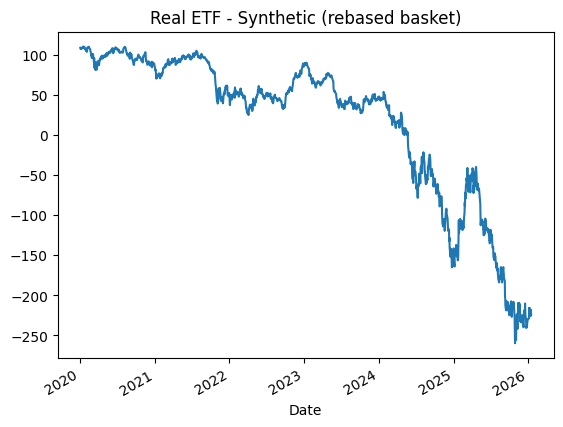

In [4]:
def synthetic_etf_rebased(prices_row: pd.Series, base_row: pd.Series, components: List[str]) -> float:
    """Capula-style synthetic ETF: rebase each component to 100 at t0, then average."""
    rebase = (prices_row[components] / base_row[components]) * 100.0
    return float(rebase.mean())

def compute_spread_series(prices: pd.DataFrame, etf: str, components: List[str]) -> pd.Series:
    base = prices.iloc[0]
    syn = prices.apply(lambda row: synthetic_etf_rebased(row, base, components), axis=1)
    real = prices[etf].astype(float)
    spread = real - syn
    spread.name = "spread"
    return spread

spread = compute_spread_series(prices, ETF_TICKER, COMPONENTS)
display(spread.to_frame().head())

plt.figure()
spread.plot()
plt.title("Real ETF - Synthetic (rebased basket)")
plt.show()


## 4) Baseline strategy (very close to your Capula logic)

{'CAGR': np.float64(1.809027989740919e-05), 'Vol': np.float64(0.0002234442044308595), 'Sharpe': np.float64(0.08107198003273218), 'MaxDD': np.float64(-0.0006500971742922079), 'Days': 1518}


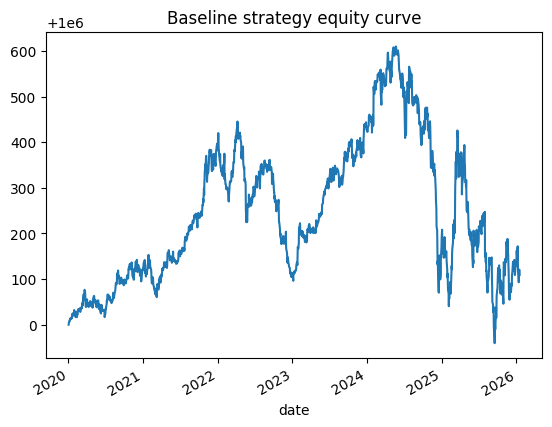

,date,ticker,qty,price,notional,cost,cash_after
0,2020-01-02,QQQ,-5.0,208.580231,-1042.901154,0.104290,1.001043e+06
1,2020-01-02,NVDA,1.0,5.971077,5.971077,0.000597,1.001037e+06
2,2020-01-02,AAPL,1.0,72.468254,72.468254,0.007247,1.000964e+06
3,2020-01-02,MSFT,1.0,152.505692,152.505692,0.015251,1.000812e+06
4,2020-01-02,AMZN,1.0,94.900497,94.900497,0.009490,1.000717e+06


In [5]:
def run_baseline_strategy(
    prices: pd.DataFrame,
    etf: str,
    components: List[str],
    etf_qty: int = 5,
    stock_qty: int = 1,
    commission_bps: float = 1.0,
    entry_on_sign: bool = True,
):
    engine = BacktestEngine(prices, initial_cash=1_000_000.0, commission_bps=commission_bps, slippage_bps=0.0)

    base_row = prices.iloc[0]
    for date, row in prices.iterrows():
        syn = synthetic_etf_rebased(row, base_row, components)
        real = float(row[etf])
        spread = real - syn

        # current ETF qty
        cur_qty = engine.positions.get(etf, Position(etf, 0.0, 0.0)).qty

        # mimic your "only enter if not already in same direction"
        if real < syn:
            # long ETF / short basket
            if cur_qty <= 0:
                engine.execute_order(date, etf, +etf_qty)
                for t in components:
                    engine.execute_order(date, t, -stock_qty)
        elif real > syn:
            # short ETF / long basket
            if cur_qty >= 0:
                engine.execute_order(date, etf, -etf_qty)
                for t in components:
                    engine.execute_order(date, t, +stock_qty)

        engine.snapshot(date)

    eq = pd.DataFrame(engine.equity_curve).set_index("date")["equity"]
    return engine, eq

baseline_engine, baseline_eq = run_baseline_strategy(prices, ETF_TICKER, COMPONENTS, etf_qty=5, stock_qty=1, commission_bps=1.0)
print(perf_summary(baseline_eq))

plt.figure()
baseline_eq.plot()
plt.title("Baseline strategy equity curve")
plt.show()

pd.DataFrame(baseline_engine.trades).head()


## 5) Improved strategy (entry/exit bands + dollar-neutral sizing + risk controls)

{'CAGR': np.float64(-0.0024542600559885885), 'Vol': np.float64(0.0031294389640107003), 'Sharpe': np.float64(-0.7836456409570235), 'MaxDD': np.float64(-0.01775907764521356), 'Days': 1518}


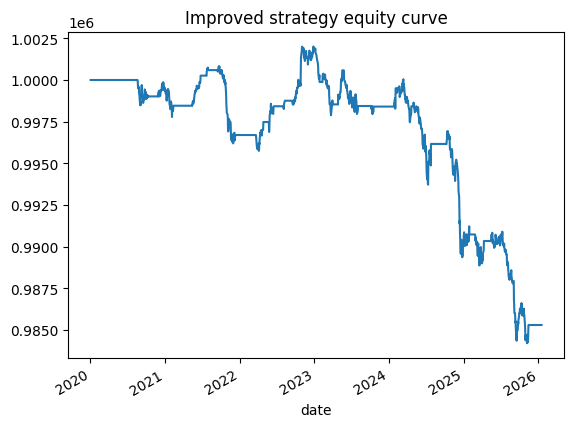

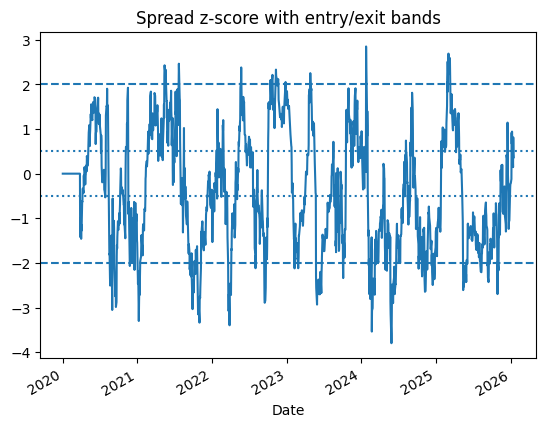

,date,ticker,qty,price,notional,cost,cash_after
0,2020-08-19,QQQ,187.0,267.450470,50013.237885,5.001324,949981.760792
1,2020-08-19,NVDA,-413.0,12.097267,-4996.171333,0.499617,954977.432508
2,2020-08-19,AAPL,-44.0,112.441757,-4947.437317,0.494744,959924.375081
3,2020-08-19,MSFT,-25.0,200.690063,-5017.251587,0.501725,964941.124943
4,2020-08-19,AMZN,-31.0,163.024002,-5053.744064,0.505374,969994.363633


In [6]:
def run_improved_strategy(
    prices: pd.DataFrame,
    etf: str,
    components: List[str],
    lookback: int = 60,
    entry_z: float = 2.0,
    exit_z: float = 0.5,
    target_notional: float = 50_000.0,
    max_gross_notional: float = 300_000.0,
    commission_bps: float = 1.0,
):
    """Improved mean-reversion: trade z-score of spread with hysteresis + sizing."""
    engine = BacktestEngine(prices, initial_cash=1_000_000.0, commission_bps=commission_bps, slippage_bps=0.0)

    spread = compute_spread_series(prices, etf, components)
    roll_mean = spread.rolling(lookback).mean()
    roll_std = spread.rolling(lookback).std().replace(0, np.nan)
    z = (spread - roll_mean) / roll_std
    z = z.fillna(0.0)

    def gross_notional(date) -> float:
        g = 0.0
        for t, pos in engine.positions.items():
            if pos.qty == 0:
                continue
            g += abs(pos.qty * engine.get_price(date, t))
        return g

    base_row = prices.iloc[0]

    for date, row in prices.iterrows():
        if date not in z.index:
            continue
        zt = float(z.loc[date])

        # Current ETF position sign (+ long, - short, 0 flat)
        etf_pos = engine.positions.get(etf, Position(etf, 0.0, 0.0)).qty
        side = 0
        if etf_pos > 0:
            side = +1
        elif etf_pos < 0:
            side = -1

        # Risk: refuse new entries if gross too high
        gnot = gross_notional(date)
        can_enter = gnot < max_gross_notional

        # Compute sizing (dollar-neutral-ish)
        etf_px = float(row[etf])
        # equal-weight basket for demo
        comp_px = row[components].astype(float)
        comp_weights = np.ones(len(components)) / len(components)

        etf_qty = int(max(1, round(target_notional / etf_px)))
        comp_qty = {t: int(max(1, round((target_notional * w) / float(comp_px[t])))) for t, w in zip(components, comp_weights)}

        # Entry logic (hysteresis)
        if side == 0 and can_enter:
            if zt <= -entry_z:
                # ETF cheap: long ETF / short basket
                engine.execute_order(date, etf, +etf_qty)
                for t in components:
                    engine.execute_order(date, t, -comp_qty[t])
            elif zt >= entry_z:
                # ETF rich: short ETF / long basket
                engine.execute_order(date, etf, -etf_qty)
                for t in components:
                    engine.execute_order(date, t, +comp_qty[t])

        # Exit logic
        elif side != 0:
            if abs(zt) <= exit_z:
                # Close all legs
                engine.execute_order(date, etf, -engine.positions[etf].qty)
                for t in components:
                    if t in engine.positions and engine.positions[t].qty != 0:
                        engine.execute_order(date, t, -engine.positions[t].qty)

        engine.snapshot(date)

    eq = pd.DataFrame(engine.equity_curve).set_index("date")["equity"]
    diagnostics = pd.DataFrame({"spread": spread, "z": z})
    return engine, eq, diagnostics

imp_engine, imp_eq, diag = run_improved_strategy(
    prices, ETF_TICKER, COMPONENTS,
    lookback=60, entry_z=2.0, exit_z=0.5,
    target_notional=50_000.0, max_gross_notional=300_000.0,
    commission_bps=1.0,
)

print(perf_summary(imp_eq))

plt.figure()
imp_eq.plot()
plt.title("Improved strategy equity curve")
plt.show()

plt.figure()
diag["z"].plot()
plt.axhline(2.0, linestyle="--")
plt.axhline(-2.0, linestyle="--")
plt.axhline(0.5, linestyle=":")
plt.axhline(-0.5, linestyle=":")
plt.title("Spread z-score with entry/exit bands")
plt.show()

pd.DataFrame(imp_engine.trades).head()


## 6) Compare strategies + quick trade log

,name,CAGR,Vol,Sharpe,MaxDD,Days,num_trades
0,baseline,0.000018,0.000223,0.081072,-0.000650,1518,77
1,improved,-0.002454,0.003129,-0.783646,-0.017759,1518,418


,date,ticker,qty,price,notional,cost,cash_after
413,2025-11-13,GOOGL,30.0,278.387909,8351.637268,0.835164,1.010643e+06
414,2025-11-13,META,8.0,609.393005,4875.144043,0.487514,1.005768e+06
415,2025-11-13,GOOG,30.0,278.938019,8368.140564,0.836814,9.973987e+05
416,2025-11-13,AVGO,22.0,339.330750,7465.276489,0.746528,9.899327e+05
417,2025-11-13,COST,5.0,925.080017,4625.400085,0.462540,9.853068e+05


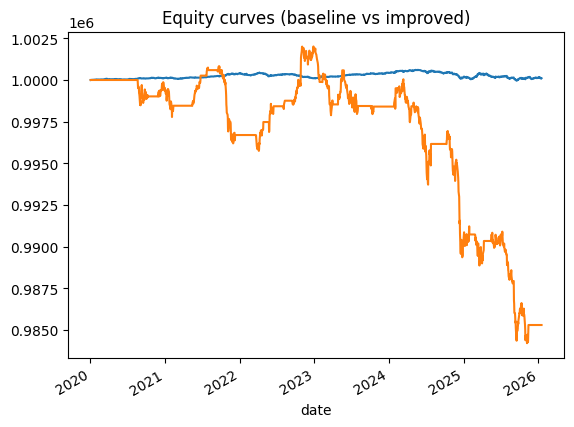

In [7]:
def summarize_engine(engine: BacktestEngine, eq: pd.Series, name: str):
    summ = perf_summary(eq)
    out = {"name": name, **summ, "num_trades": len(engine.trades)}
    return out

summary = pd.DataFrame([
    summarize_engine(baseline_engine, baseline_eq, "baseline"),
    summarize_engine(imp_engine, imp_eq, "improved"),
])

display(summary)

trades_df = pd.DataFrame(imp_engine.trades)
display(trades_df.tail())

# Overlay equity curves
plt.figure()
baseline_eq.rename("baseline").plot()
imp_eq.rename("improved").plot()
plt.title("Equity curves (baseline vs improved)")
plt.show()


## 7) Interview talking points (what to say while demo-ing)

- **Research hygiene**: caching data, keeping assumptions explicit, preventing look-ahead.
- **Baseline vs improved**: baseline enters on sign; improved uses **z-score + hysteresis** to reduce churn.
- **Sizing**: dollar-neutralish with target notional; highlight why fixed lots can create unintended exposure.
- **Risk**: gross notional cap; explain how you’d add slippage model, borrow, liquidity constraints.
- **Next upgrade**: estimate hedge ratios via regression (ETF returns vs components) and rebalance periodically.

Simulation Range: 2015-01-02 to 2026-01-16
Total Trading Days: 2777
Ticker           AAPL     AMZN      AVGO        COST       GOOG      GOOGL  \
Date                                                                         
2015-01-02  24.237551  15.4260  7.560339  114.136024  25.973848  26.278944   
2015-01-05  23.554737  15.1095  7.439483  112.838417  25.432405  25.778225   
2015-01-06  23.556965  14.7645  7.270284  114.329475  24.842955  25.142036   
2015-01-07  23.887276  14.9210  7.466675  116.320259  24.800392  25.068092   
2015-01-08  24.805079  15.0230  7.839818  117.319656  24.878590  25.155436   

Ticker           META       MSFT      NVDA  ETF_PROXY       TSLA  
Date                                                              
2015-01-02  77.905800  39.858448  0.483011  94.784439  14.620667  
2015-01-05  76.654556  39.491920  0.474853  93.394081  14.006000  
2015-01-06  75.621758  38.912300  0.460457  92.141800  14.085333  
2015-01-07  75.621758  39.406673  0.459257  93.329

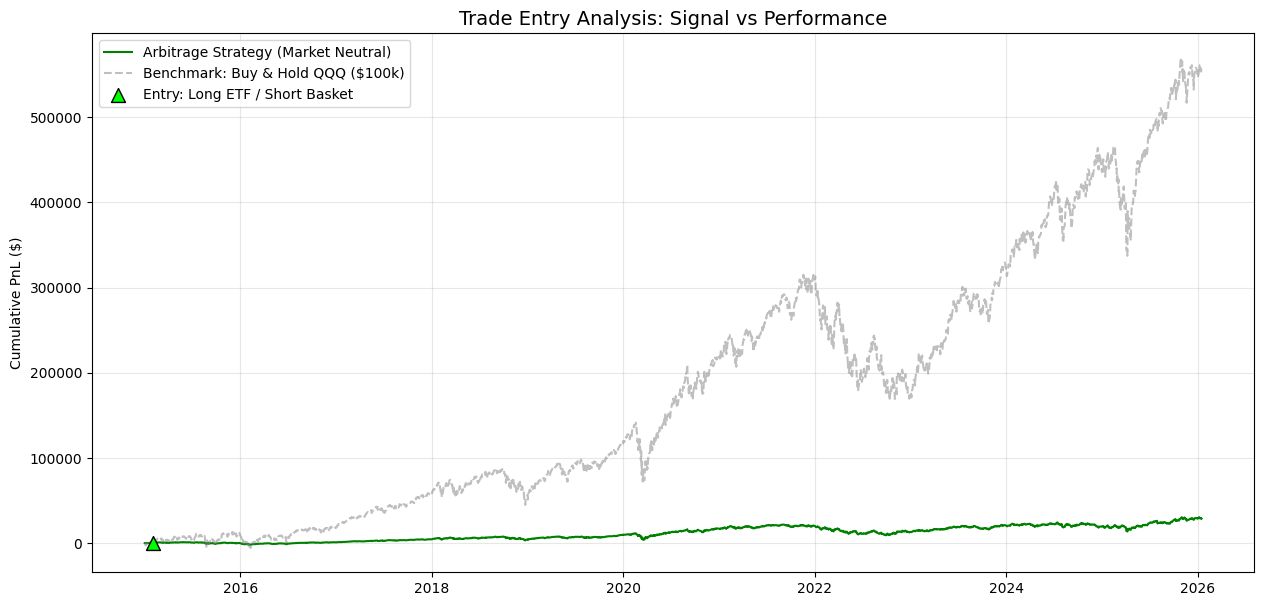

Total Trades: 11
Directional Flips (ETF Trades): 1


In [16]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
import warnings

# Suppress pandas warnings for a cleaner demo
warnings.filterwarnings('ignore')

# ==========================================
# 1. TRADING ENGINE (The Infrastructure)
# ==========================================
class CurrentPosition:
    def __init__(self, ticker, price, volume, action, date):
        self.ticker = ticker
        self.direction = "LONG" if action == "BUY" else "SHORT"
        self.position_volume = volume if self.direction == "LONG" else -volume
        self.open_price = price
        self.current_price = price
        self.commission_costs = 0.0
        self.trade_history = [{'action': action, 'price': price, 'volume': volume, 'date': date}]

    def update_price(self, price):
        self.current_price = price

    @property
    def profit_loss(self):
        # Mark-to-Market PnL
        val = (self.current_price - self.open_price) * self.position_volume
        return val - self.commission_costs

class TradingEngine:
    def __init__(self, commission_percentage=0.005):
        self.commission_percentage = commission_percentage
        self.current_positions = {} 
        self.cash_balance = 100000.0 
        self.realized_pnl = 0.0
        self.history = []

    def execute_order(self, ticker, volume, action, date, current_price):
        """Executes trade and updates internal state."""
        cost = current_price * volume * self.commission_percentage
        self.cash_balance -= cost
        self.history.append({
            'date': date, 'ticker': ticker, 'action': action, 
            'volume': volume, 'price': current_price, 'comm': cost
        })

        if ticker in self.current_positions:
            pos = self.current_positions[ticker]
            pos.update_price(current_price)
            
            # If trading against current position (e.g. LONG -> SELL), close it
            if (pos.direction == "LONG" and action == "SELL") or \
               (pos.direction == "SHORT" and action == "BUY"):
                
                trade_pnl = (current_price - pos.open_price) * pos.position_volume 
                self.realized_pnl += trade_pnl - pos.commission_costs - cost
                del self.current_positions[ticker] 
            else:
                # Adding to position (simplified)
                pos.position_volume += volume if action == "BUY" else -volume
                pos.commission_costs += cost
        else:
            # New Position
            new_pos = CurrentPosition(ticker, current_price, volume, action, date)
            new_pos.commission_costs = cost
            self.current_positions[ticker] = new_pos

    def get_total_pnl(self, current_prices_map):
        unrealized = 0
        for ticker, pos in self.current_positions.items():
            if ticker in current_prices_map:
                current_price = current_prices_map[ticker]
                unrealized += (current_price - pos.open_price) * pos.position_volume - pos.commission_costs
        return self.realized_pnl + unrealized

# ==========================================
# 2. DATA GENERATOR (Robust Handling)
# ==========================================
def get_aligned_market_data():
    """
    Fetches QQQ and its top components.
    """
    # Components + ETF (FNGS = MicroSectors FANG+ ETN)
    tickers = ["NVDA","AAPL","MSFT","AMZN","TSLA","GOOGL","META","GOOG","AVGO","COST"]
    etf_ticker = 'QQQ' 
    
    print(f"Downloading data for {len(tickers)} stocks + {etf_ticker}...")
    
    # Download all
    data = yf.download(tickers + [etf_ticker], start="2015-01-01", end=date.today(), progress=False)['Close']
    
    # CRITICAL: Drop rows where ANY stock is missing. 
    # This automatically finds the common start date (likely Sept 2020 due to PLTR).
    data = data.dropna()
    
    # Rename ETF column for strategy logic
    data.rename(columns={etf_ticker: 'ETF_PROXY'}, inplace=True)
    
    print(f"Simulation Range: {data.index.min().date()} to {data.index.max().date()}")
    print(f"Total Trading Days: {len(data)}")
    return data

# ==========================================
# 3. STRATEGY LOGIC (The "Student" Code)
# ==========================================
def run_arbitrage_strategy(prices_df, engine, date):
    # Separate ETF from Components
    tickers = prices_df.columns.tolist()
    etf_col = "ETF_PROXY"
    components = [t for t in tickers if t != etf_col]

    # 1. Define Reference Point (t0) for normalization
    # In a real strategy, this might be a rolling window, but here we use start-of-period
    prices_t0 = prices_df.iloc[0]
    current_prices = prices_df.loc[date]
    
    # 2. Compute Synthetic ETF Value (Normalized to 100)
    # logic: If AAPL went 100->110, it contributes 110 to the index
    rebased_components = (current_prices[components] / prices_t0[components]) * 100
    syn_etf_value = rebased_components.mean()
    
    # 3. Compute Real ETF Value (Normalized to 100)
    # We MUST normalize the real ETF too, otherwise we compare Price ($300) vs Index (100)
    real_etf_raw_price = current_prices[etf_col]
    real_etf_normalized = (real_etf_raw_price / prices_t0[etf_col]) * 100
    
    # 4. Calculate Spread
    spread = real_etf_normalized - syn_etf_value
    
    # 5. Trading Parameters
    threshold = 2.0  # Divergence threshold (e.g., 2% difference)
    etf_vol = 200    # Volume to trade
    stock_vol = 20   # Volume per stock (approx hedge ratio)

    try:
        # Check current exposure
        current_pos_vol = 0
        if etf_col in engine.current_positions:
            current_pos_vol = engine.current_positions[etf_col].position_volume
        
        # --- Signal Generation ---
        
        # Case A: Real ETF is Cheap (Undervalued vs Synthetic) -> BUY ETF, SELL Basket
        if spread < -threshold:
            if current_pos_vol <= 0: # Only enter if flat or short
                engine.execute_order(etf_col, etf_vol, "BUY", date, real_etf_raw_price)
                for t in components:
                    engine.execute_order(t, stock_vol, "SELL", date, current_prices[t])
                    
        # Case B: Real ETF is Expensive (Overvalued vs Synthetic) -> SELL ETF, BUY Basket
        elif spread > threshold:
            if current_pos_vol >= 0: # Only enter if flat or long
                engine.execute_order(etf_col, etf_vol, "SELL", date, real_etf_raw_price)
                for t in components:
                    engine.execute_order(t, stock_vol, "BUY", date, current_prices[t])

    except Exception as e:
        print(f"Error on {date}: {e}")

# ==========================================
# 4. MAIN EXECUTION LOOP
# ==========================================
# A. Get Data
df = get_aligned_market_data()
print(df.head())

# B. Initialize Engine
engine = TradingEngine(commission_percentage=0.001) # 10bps commission

# C. Run Simulation
print("Running Backtest...")
pnl_history = []
dates = df.index

for d in dates:
    run_arbitrage_strategy(df, engine, d)
    
    # Mark to Market Calculation
    todays_prices = df.loc[d].to_dict()
    daily_pnl = engine.get_total_pnl(todays_prices)
    pnl_history.append(daily_pnl)

# ==========================================
# 5. VISUALIZATION
# ==========================================
plt.figure(figsize=(15, 7))

# 1. Plot the PnL Curves
plt.plot(dates, pnl_history, label='Arbitrage Strategy (Market Neutral)', color='green', linewidth=1.5)
plt.plot(dates, benchmark_pnl, label='Benchmark: Buy & Hold QQQ ($100k)', color='gray', linestyle='--', alpha=0.5)

# 2. Extract Trade Signals
trades_df = pd.DataFrame(engine.history)
if not trades_df.empty:
    # Filter for ETF trades only to see the "Spread Direction"
    etf_trades = trades_df[trades_df['ticker'] == 'ETF_PROXY']
    
    # "BUY" ETF = Long Spread (Betting ETF will rise vs Basket)
    buys = etf_trades[etf_trades['action'] == 'BUY']
    # "SELL" ETF = Short Spread (Betting ETF will fall vs Basket)
    sells = etf_trades[etf_trades['action'] == 'SELL']

    # 3. Overlay Markers
    # We use the PnL value at that date for the Y-coordinate
    if not buys.empty:
        buy_dates = pd.to_datetime(buys['date'])
        # Get PnL values for these dates. We might need to map dates to indices if exact match fails
        buy_y = [pnl_history[dates.get_loc(d)] for d in buy_dates if d in dates] 
        buy_x = [d for d in buy_dates if d in dates]
        
        plt.scatter(buy_x, buy_y, marker='^', color='lime', s=100, edgecolors='black', 
                    label='Entry: Long ETF / Short Basket', zorder=5)

    if not sells.empty:
        sell_dates = pd.to_datetime(sells['date'])
        sell_y = [pnl_history[dates.get_loc(d)] for d in sell_dates if d in dates]
        sell_x = [d for d in sell_dates if d in dates]
        
        plt.scatter(sell_x, sell_y, marker='v', color='red', s=100, edgecolors='black', 
                    label='Entry: Short ETF / Long Basket', zorder=5)

# 4. Formatting
plt.title('Trade Entry Analysis: Signal vs Performance', fontsize=14)
plt.ylabel('Cumulative PnL ($)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 5. Diagnostic Print
if not trades_df.empty:
    print(f"Total Trades: {len(trades_df)}")
    print(f"Directional Flips (ETF Trades): {len(etf_trades)}")
else:
    print("No trades executed. Check thresholds.")